<a href="https://colab.research.google.com/github/Adi-Arora1/Bird_or_forest_DeepLearning/blob/main/BirdOrNot_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -Uqq fastai

In [2]:
!pip install duckduckgo-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 53.9 MB/s eta 0:00:00


In [ ]:
import requests
import time
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# **calling pexels api to fetch images for a "term"**

In [3]:
from duckduckgo_search import DDGS
import warnings
warnings.filterwarnings('ignore')
from fastcore.all import L
# Sign up at https://www.pexels.com/api/
PEXELS_KEY = 'hHDrcgbFBF5xya4QMF9xWvO0AG4p2pGBuQL13Ow3ffr7yHy8TZzVZADo'

def search_images(term, max_images=100):
    url = "https://api.pexels.com/v1/search"
    headers = {'Authorization': PEXELS_KEY}
    params = {'query': term, 'per_page': max_images}
    res = requests.get(url, headers=headers, params=params).json()
    urls = L([r['src']['large'] for r in res['photos']])
    print(f"Found {len(urls)} images")
    return urls

# Fetching and showcasing the image


Found 1 images
https://images.pexels.com/photos/13860114/pexels-photo-13860114.jpeg?auto=compress&cs=tinysrgb&h=650&w=940


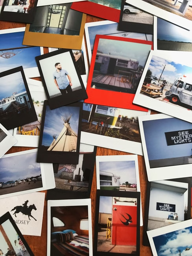

In [72]:
import requests
import time
from PIL import Image
warnings.filterwarnings('ignore')

# Step 1 - search first
urls = search_images('random', max_images=1)
print(urls[0])  # verify URL exists

# Step 2 - wait a moment
time.sleep(3)

# Step 3 - then download
download_url(urls[0], 'bird.jpg', show_progress=False)

# Step 4 - display
Image.open('bird.jpg').to_thumb(256, 256)

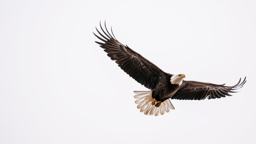

In [53]:
from fastdownload import download_url
import warnings
warnings.filterwarnings('ignore')
dest = 'bird.jpeg'
download_url(urls[0], dest,show_progress = False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)


In [10]:
searches = 'forest','bird'
path = Path('bird_or_not')
for o in searches:
  dest = (path/o)
  dest.mkdir(exist_ok=True, parents=True)
  download_images(dest, urls=search_images(f'{o} photo'))
  resize_images(path/o, max_size=400, dest=path/o)

Found 80 images
Found 80 images


# Model Training


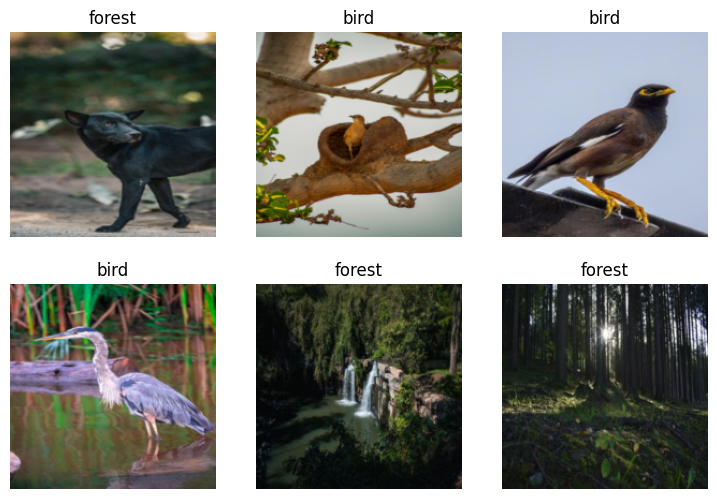

In [14]:
dls = DataBlock(
    blocks = (ImageBlock,CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct=0.2, seed=42),
    get_y = parent_label,
    item_tfms = [Resize(192,method = 'squish')]
).dataloaders(path)
dls.show_batch(max_n = 6)

In [15]:
learn = vision_learner(dls,resnet18,metrics = error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.121174,1.360831,0.290323,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.531748,0.613714,0.193548,00:20
1,0.371240,0.312615,0.096774,00:21
2,0.284329,0.267760,0.096774,00:20


# Model Usage

In [74]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a target: {probs[0]:.4f}")


This is a: forest.
Probability it's a target: 0.0432
